# Esports Match Outcome Prediction Using Deep Learning
## Complete Exploratory Data Analysis (EDA)

This notebook is designed to run in Google Colab. Upload `games.csv` when prompted.

In [3]:
# Install/verify required libraries
!pip -q install pandas numpy matplotlib seaborn

In [4]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
# Upload games.csv in Google Colab
from google.colab import files

uploaded = files.upload()

print("Upload completed!")

Saving games.csv to games (1).csv
Upload completed!


In [6]:
# Load the dataset
import os

csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]
print("CSV files found:", csv_files)

file_name = 'games.csv' if 'games.csv' in csv_files else csv_files[0]
df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

CSV files found: ['games (1).csv', 'games.csv']
Dataset loaded successfully!
Dataset shape: (51490, 61)


In [7]:
# Display first 5 rows
df.head()

,gameId,creationTime,gameDuration,seasonId,winner,firstBlood,firstTower,firstInhibitor,firstBaron,firstDragon,firstRiftHerald,t1_champ1id,t1_champ1_sum1,t1_champ1_sum2,t1_champ2id,t1_champ2_sum1,t1_champ2_sum2,t1_champ3id,t1_champ3_sum1,t1_champ3_sum2,t1_champ4id,t1_champ4_sum1,t1_champ4_sum2,t1_champ5id,t1_champ5_sum1,t1_champ5_sum2,t1_towerKills,t1_inhibitorKills,t1_baronKills,t1_dragonKills,t1_riftHeraldKills,t1_ban1,t1_ban2,t1_ban3,t1_ban4,t1_ban5,t2_champ1id,t2_champ1_sum1,t2_champ1_sum2,t2_champ2id,t2_champ2_sum1,t2_champ2_sum2,t2_champ3id,t2_champ3_sum1,t2_champ3_sum2,t2_champ4id,t2_champ4_sum1,t2_champ4_sum2,t2_champ5id,t2_champ5_sum1,t2_champ5_sum2,t2_towerKills,t2_inhibitorKills,t2_baronKills,t2_dragonKills,t2_riftHeraldKills,t2_ban1,t2_ban2,t2_ban3,t2_ban4,t2_ban5
0,3326086514,1504279457970,1949,9,1,2,1,1,1,1,2,8,12,4,432,3,4,96,4,7,11,11,6,112,4,14,11,1,2,3,0,92,40,69,119,141,104,11,4,498,4,7,122,6,4,238,14,4,412,4,3,5,0,0,1,1,114,67,43,16,51
1,3229566029,1497848803862,1851,9,1,1,1,1,0,1,1,119,7,4,39,12,4,76,4,3,10,4,14,35,4,11,10,4,0,2,1,51,122,17,498,19,54,4,12,25,4,14,120,11,4,157,4,14,92,4,7,2,0,0,0,0,11,67,238,51,420
2,3327363504,1504360103310,1493,9,1,2,1,1,1,2,0,18,4,7,141,11,4,267,3,4,68,4,12,38,12,4,8,1,1,1,0,117,40,29,16,53,69,4,7,412,14,4,126,4,12,24,4,11,22,7,4,2,0,0,1,0,157,238,121,57,28
3,3326856598,1504348503996,1758,9,1,1,1,1,1,1,0,57,4,12,63,4,14,29,4,7,61,4,1,36,11,4,9,2,1,2,0,238,67,516,114,31,90,14,4,19,11,4,412,4,3,92,4,14,22,4,7,0,0,0,0,0,164,18,141,40,51
4,3330080762,1504554410899,2094,9,1,2,1,1,1,1,0,19,4,12,29,11,4,40,4,3,119,4,7,134,7,4,9,2,1,3,0,90,64,412,25,31,37,3,4,59,4,12,141,11,4,38,4,12,51,4,7,3,0,0,1,0,86,11,201,122,18


In [8]:
# Display last 5 rows
df.tail()

,gameId,creationTime,gameDuration,seasonId,winner,firstBlood,firstTower,firstInhibitor,firstBaron,firstDragon,firstRiftHerald,t1_champ1id,t1_champ1_sum1,t1_champ1_sum2,t1_champ2id,t1_champ2_sum1,t1_champ2_sum2,t1_champ3id,t1_champ3_sum1,t1_champ3_sum2,t1_champ4id,t1_champ4_sum1,t1_champ4_sum2,t1_champ5id,t1_champ5_sum1,t1_champ5_sum2,t1_towerKills,t1_inhibitorKills,t1_baronKills,t1_dragonKills,t1_riftHeraldKills,t1_ban1,t1_ban2,t1_ban3,t1_ban4,t1_ban5,t2_champ1id,t2_champ1_sum1,t2_champ1_sum2,t2_champ2id,t2_champ2_sum1,t2_champ2_sum2,t2_champ3id,t2_champ3_sum1,t2_champ3_sum2,t2_champ4id,t2_champ4_sum1,t2_champ4_sum2,t2_champ5id,t2_champ5_sum1,t2_champ5_sum2,t2_towerKills,t2_inhibitorKills,t2_baronKills,t2_dragonKills,t2_riftHeraldKills,t2_ban1,t2_ban2,t2_ban3,t2_ban4,t2_ban5
51485,3308904636,1503076540231,1944,9,2,1,2,2,0,2,0,19,12,4,429,4,7,91,4,14,432,4,14,64,4,11,2,0,0,0,0,114,18,11,157,497,45,12,4,83,12,4,67,4,7,40,3,4,79,11,4,10,2,0,4,0,55,-1,90,238,157
51486,3215685759,1496957179355,3304,9,2,1,1,2,2,2,2,90,4,14,32,4,11,31,12,4,412,14,4,18,4,7,5,4,0,2,0,157,164,122,99,420,102,11,4,429,7,4,89,3,4,75,4,12,45,14,4,11,7,4,4,1,157,55,119,154,105
51487,3322765040,1504029863961,2156,9,2,2,2,2,0,1,0,141,11,4,18,7,4,432,3,4,81,12,4,68,4,12,0,0,0,1,0,238,31,24,53,11,1,4,12,119,7,4,33,11,4,43,12,4,99,14,4,10,2,0,2,0,113,122,53,11,157
51488,3256675373,1499562036246,1475,9,2,2,2,2,0,2,0,121,11,4,236,4,7,420,4,12,201,4,3,99,4,14,0,0,0,0,0,119,64,51,157,29,21,7,4,56,4,12,25,4,14,30,12,4,11,11,4,11,3,0,1,0,154,39,51,90,114
51489,3317333020,1503612754059,1445,9,1,1,1,1,1,2,0,89,3,4,1,4,14,164,4,12,113,11,4,202,4,7,11,3,1,2,0,40,122,96,157,117,63,4,14,17,14,4,29,7,4,121,11,4,58,12,4,1,0,0,1,0,11,157,141,31,18


In [9]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51490 entries, 0 to 51489
Data columns (total 61 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   gameId              51490 non-null  int64
 1   creationTime        51490 non-null  int64
 2   gameDuration        51490 non-null  int64
 3   seasonId            51490 non-null  int64
 4   winner              51490 non-null  int64
 5   firstBlood          51490 non-null  int64
 6   firstTower          51490 non-null  int64
 7   firstInhibitor      51490 non-null  int64
 8   firstBaron          51490 non-null  int64
 9   firstDragon         51490 non-null  int64
 10  firstRiftHerald     51490 non-null  int64
 11  t1_champ1id         51490 non-null  int64
 12  t1_champ1_sum1      51490 non-null  int64
 13  t1_champ1_sum2      51490 non-null  int64
 14  t1_champ2id         51490 non-null  int64
 15  t1_champ2_sum1      51490 non-null  int64
 16  t1_champ2_sum2      51490 non-null  int6

In [10]:
# Dataset dimensions
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 51490
Number of Columns: 61


In [11]:
# Column names
print("Column Names:")
for col in df.columns:
    print(col)

Column Names:
gameId
creationTime
gameDuration
seasonId
winner
firstBlood
firstTower
firstInhibitor
firstBaron
firstDragon
firstRiftHerald
t1_champ1id
t1_champ1_sum1
t1_champ1_sum2
t1_champ2id
t1_champ2_sum1
t1_champ2_sum2
t1_champ3id
t1_champ3_sum1
t1_champ3_sum2
t1_champ4id
t1_champ4_sum1
t1_champ4_sum2
t1_champ5id
t1_champ5_sum1
t1_champ5_sum2
t1_towerKills
t1_inhibitorKills
t1_baronKills
t1_dragonKills
t1_riftHeraldKills
t1_ban1
t1_ban2
t1_ban3
t1_ban4
t1_ban5
t2_champ1id
t2_champ1_sum1
t2_champ1_sum2
t2_champ2id
t2_champ2_sum1
t2_champ2_sum2
t2_champ3id
t2_champ3_sum1
t2_champ3_sum2
t2_champ4id
t2_champ4_sum1
t2_champ4_sum2
t2_champ5id
t2_champ5_sum1
t2_champ5_sum2
t2_towerKills
t2_inhibitorKills
t2_baronKills
t2_dragonKills
t2_riftHeraldKills
t2_ban1
t2_ban2
t2_ban3
t2_ban4
t2_ban5


In [12]:
# Statistical summary
df.describe(include='all')

,gameId,creationTime,gameDuration,seasonId,winner,firstBlood,firstTower,firstInhibitor,firstBaron,firstDragon,firstRiftHerald,t1_champ1id,t1_champ1_sum1,t1_champ1_sum2,t1_champ2id,t1_champ2_sum1,t1_champ2_sum2,t1_champ3id,t1_champ3_sum1,t1_champ3_sum2,t1_champ4id,t1_champ4_sum1,t1_champ4_sum2,t1_champ5id,t1_champ5_sum1,t1_champ5_sum2,t1_towerKills,t1_inhibitorKills,t1_baronKills,t1_dragonKills,t1_riftHeraldKills,t1_ban1,t1_ban2,t1_ban3,t1_ban4,t1_ban5,t2_champ1id,t2_champ1_sum1,t2_champ1_sum2,t2_champ2id,t2_champ2_sum1,t2_champ2_sum2,t2_champ3id,t2_champ3_sum1,t2_champ3_sum2,t2_champ4id,t2_champ4_sum1,t2_champ4_sum2,t2_champ5id,t2_champ5_sum1,t2_champ5_sum2,t2_towerKills,t2_inhibitorKills,t2_baronKills,t2_dragonKills,t2_riftHeraldKills,t2_ban1,t2_ban2,t2_ban3,t2_ban4,t2_ban5
count,5.149000e+04,5.149000e+04,51490.000000,51490.0,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000
mean,3.306223e+09,1.502926e+12,1832.362808,9.0,1.493552,1.471295,1.450631,1.308487,0.926510,1.442804,0.731676,114.293397,6.601787,7.333929,118.101631,6.547796,7.198213,116.905127,6.542280,7.200602,117.657953,6.530511,7.221441,114.601748,6.622412,7.261235,5.699359,1.017537,0.372286,1.387182,0.251466,108.319713,108.786094,108.205904,107.630491,109.027287,115.852088,6.595261,7.305457,117.580618,6.546630,7.230627,117.481103,6.521849,7.227384,118.185881,6.535424,7.201476,115.941853,6.612682,7.249680,5.549466,0.985084,0.414547,1.404370,0.240105,108.216294,107.910216,108.690581,108.626044,108.066576
std,2.946096e+07,1.978026e+09,512.017696,0.0,0.499963,0.520326,0.542848,0.676097,0.841424,0.569579,0.822526,119.000867,4.025601,4.299902,123.577538,3.980675,4.224076,122.653184,3.966289,4.243279,123.354082,3.965559,4.244099,120.042622,4.020005,4.257531,3.799808,1.263934,0.583934,1.206818,0.433860,102.247492,102.942617,102.660955,103.000610,102.433377,121.694131,4.028611,4.280467,123.297642,3.976676,4.256462,122.939051,3.960422,4.242333,124.002327,3.963142,4.235044,122.015086,4.013472,4.253408,3.860989,1.256284,0.613768,1.224492,0.427151,102.551787,102.870710,102.592145,103.346952,102.756149
min,3.214824e+09,1.496892e+12,190.000000,9.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,3.292218e+09,1.502021e+12,1531.000000,9.0,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,35.000000,4.000000,4.000000,35.000000,4.000000,4.000000,35.000000,4.000000,4.000000,36.000000,4.000000,4.000000,35.000000,4.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,38.000000,38.000000,37.000000,38.000000,38.000000,35.000000,4.000000,4.000000,35.000000,4.000000,4.000000,36.000000,4.000000,4.000000,35.000000,4.000000,4.000000,35.000000,4.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,38.000000,37.000000,38.000000,38.000000,38.000000
50%,3.320021e+09,1.503844e+12,1833.000000,9.0,1.000000,1.000000,1.000000,1.

In [13]:
# Missing value analysis
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

print("\nTotal Missing Values:", df.isnull().sum().sum())

Series([], dtype: int64)

Total Missing Values: 0


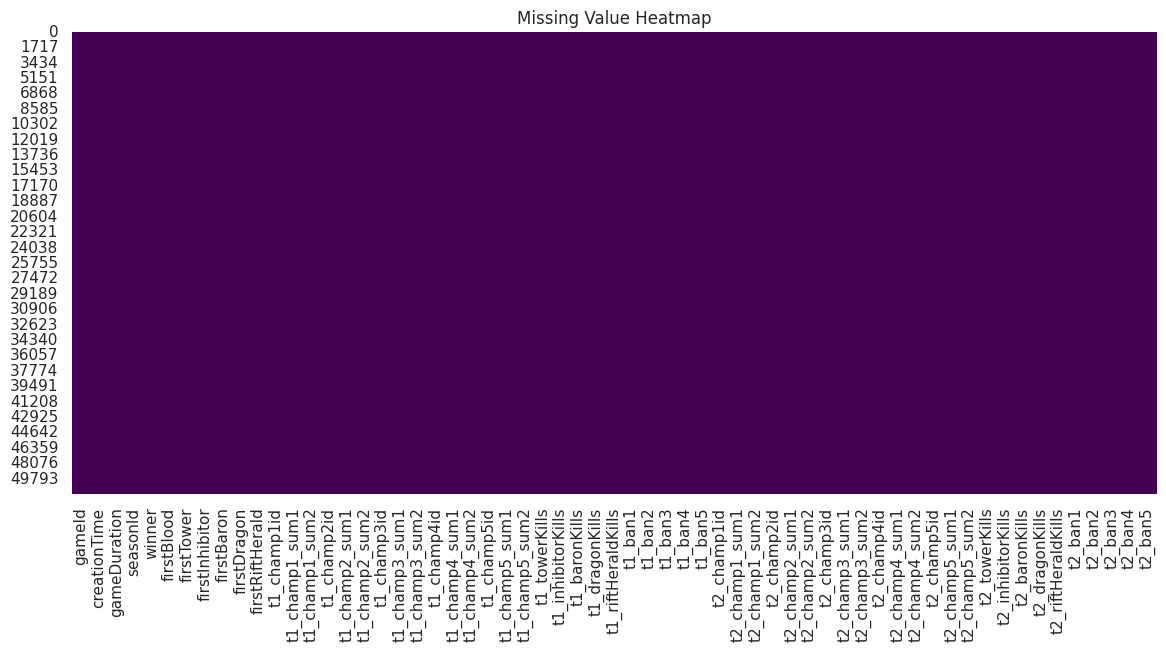

In [14]:
# Missing values visualization
plt.figure(figsize=(14, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Value Heatmap")
plt.show()

In [15]:
# Duplicate rows
duplicates = df.duplicated().sum()
print("Total Duplicate Rows:", duplicates)

Total Duplicate Rows: 437


## Target Variable Analysis

In [16]:
# Check target variable
if 'winner' not in df.columns:
    raise ValueError("The column 'winner' was not found. Please check the dataset columns.")

print(df['winner'].value_counts())
print("\nPercentage Distribution:")
print(df['winner'].value_counts(normalize=True) * 100)

winner
1    26077
2    25413
Name: count, dtype: int64

Percentage Distribution:
winner
1    50.644785
2    49.355215
Name: proportion, dtype: float64


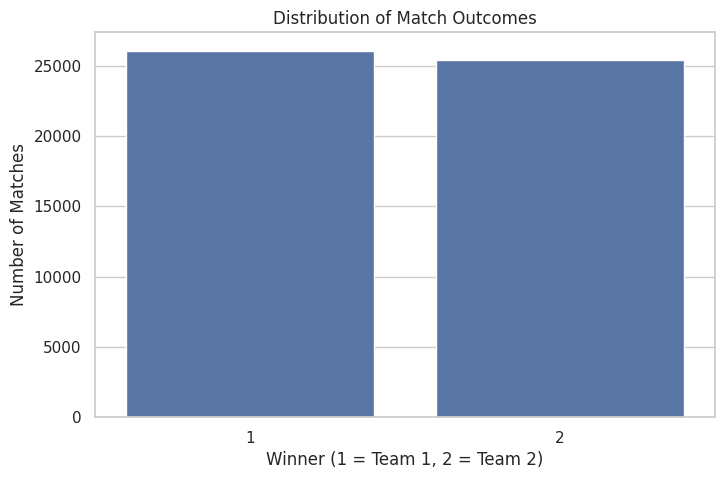

In [17]:
# Match outcome distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='winner')
plt.title("Distribution of Match Outcomes")
plt.xlabel("Winner (1 = Team 1, 2 = Team 2)")
plt.ylabel("Number of Matches")
plt.show()

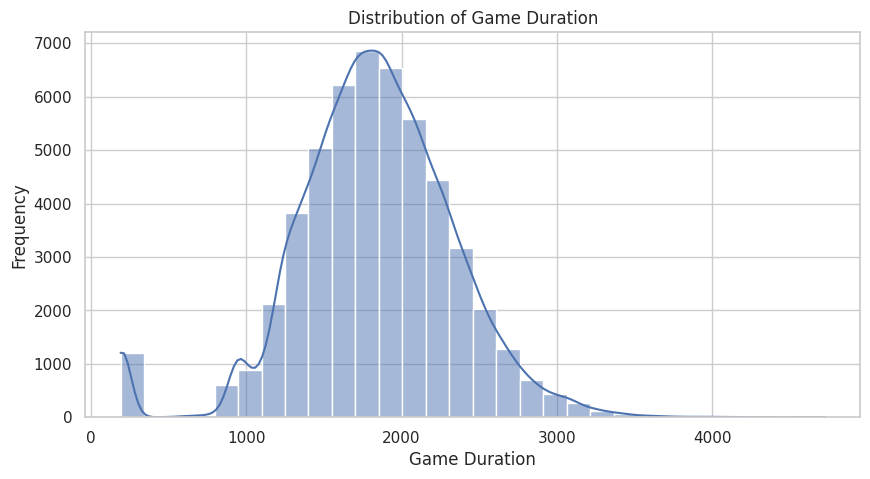

In [18]:
# Game duration distribution
if 'gameDuration' in df.columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(df['gameDuration'], bins=30, kde=True)
    plt.title("Distribution of Game Duration")
    plt.xlabel("Game Duration")
    plt.ylabel("Frequency")
    plt.show()
else:
    print("gameDuration column not found.")

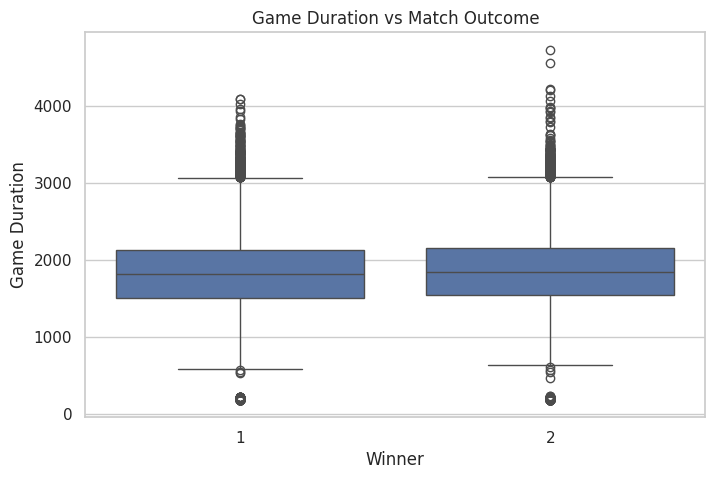

In [19]:
# Game duration vs winner
if {'winner', 'gameDuration'}.issubset(df.columns):
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='winner', y='gameDuration')
    plt.title("Game Duration vs Match Outcome")
    plt.xlabel("Winner")
    plt.ylabel("Game Duration")
    plt.show()

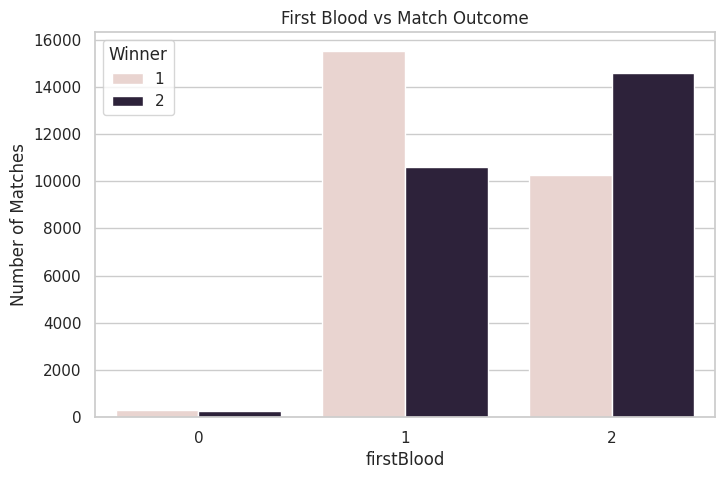

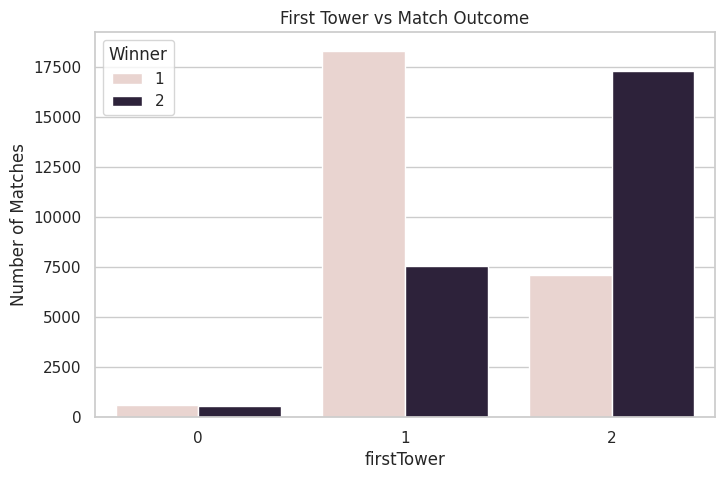

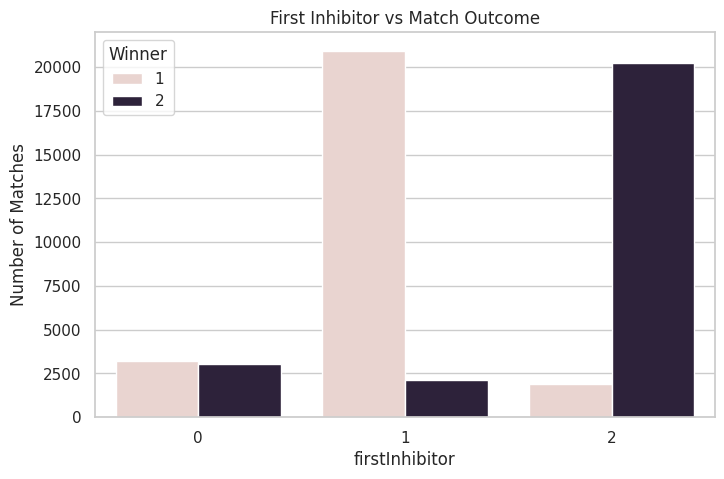

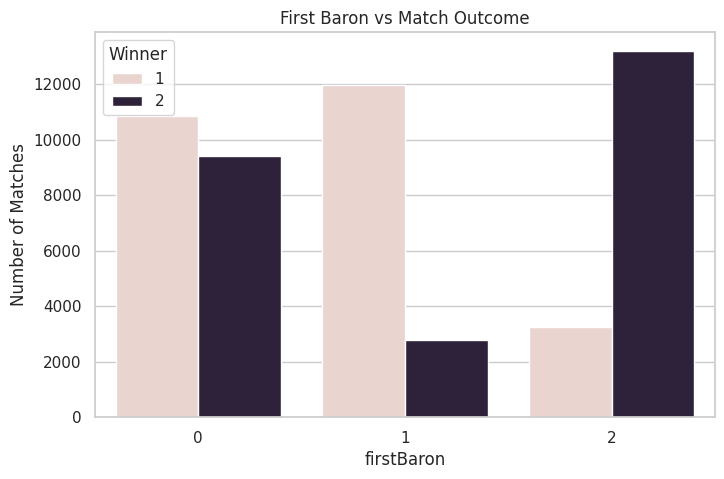

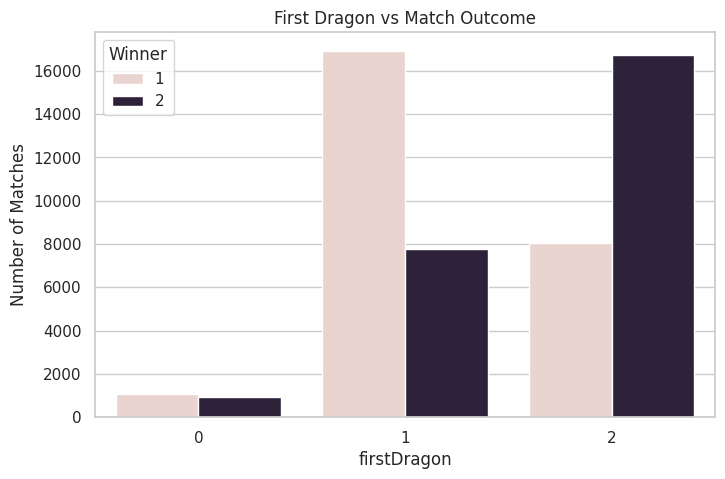

In [20]:
# Helper function for first-objective analysis
def plot_first_objective(column, title):
    if column in df.columns:
        plt.figure(figsize=(8, 5))
        sns.countplot(data=df, x=column, hue='winner')
        plt.title(title)
        plt.xlabel(column)
        plt.ylabel("Number of Matches")
        plt.legend(title="Winner")
        plt.show()
    else:
        print(f"{column} column not found.")

plot_first_objective('firstBlood', 'First Blood vs Match Outcome')
plot_first_objective('firstTower', 'First Tower vs Match Outcome')
plot_first_objective('firstInhibitor', 'First Inhibitor vs Match Outcome')
plot_first_objective('firstBaron', 'First Baron vs Match Outcome')
plot_first_objective('firstDragon', 'First Dragon vs Match Outcome')

In [21]:
# Important features available in the dataset
candidate_features = [
    'gameDuration',
    'firstBlood', 'firstTower', 'firstInhibitor', 'firstBaron', 'firstDragon',
    't1_towerKills', 't1_inhibitorKills', 't1_baronKills',
    't1_dragonKills', 't1_riftHeraldKills',
    't2_towerKills', 't2_inhibitorKills', 't2_baronKills',
    't2_dragonKills', 't2_riftHeraldKills',
    'winner'
]

important_features = [c for c in candidate_features if c in df.columns]
print("Important features found:")
print(important_features)

Important features found:
['gameDuration', 'firstBlood', 'firstTower', 'firstInhibitor', 'firstBaron', 'firstDragon', 't1_towerKills', 't1_inhibitorKills', 't1_baronKills', 't1_dragonKills', 't1_riftHeraldKills', 't2_towerKills', 't2_inhibitorKills', 't2_baronKills', 't2_dragonKills', 't2_riftHeraldKills', 'winner']


In [22]:
# Correlation matrix
numeric_important = df[important_features].select_dtypes(include=np.number)

correlation = numeric_important.corr()
print(correlation)

                    gameDuration  firstBlood  firstTower  firstInhibitor  \
gameDuration            1.000000    0.105022    0.216842        0.379996   
firstBlood              0.105022    1.000000    0.263866        0.169761   
firstTower              0.216842    0.263866    1.000000        0.380326   
firstInhibitor          0.379996    0.169761    0.380326        1.000000   
firstBaron              0.487788    0.077293    0.165028        0.417848   
firstDragon             0.255563    0.189092    0.403552        0.352760   
t1_towerKills           0.369478   -0.128116   -0.316477       -0.276349   
t1_inhibitorKills       0.301616   -0.098918   -0.240035       -0.269425   
t1_baronKills           0.397987   -0.030571   -0.056867       -0.076762   
t1_dragonKills          0.409414   -0.082820   -0.201023       -0.161124   
t1_riftHeraldKills      0.006769   -0.081243   -0.188326       -0.100527   
t2_towerKills           0.396769    0.223657    0.511296        0.755335   
t2_inhibitor

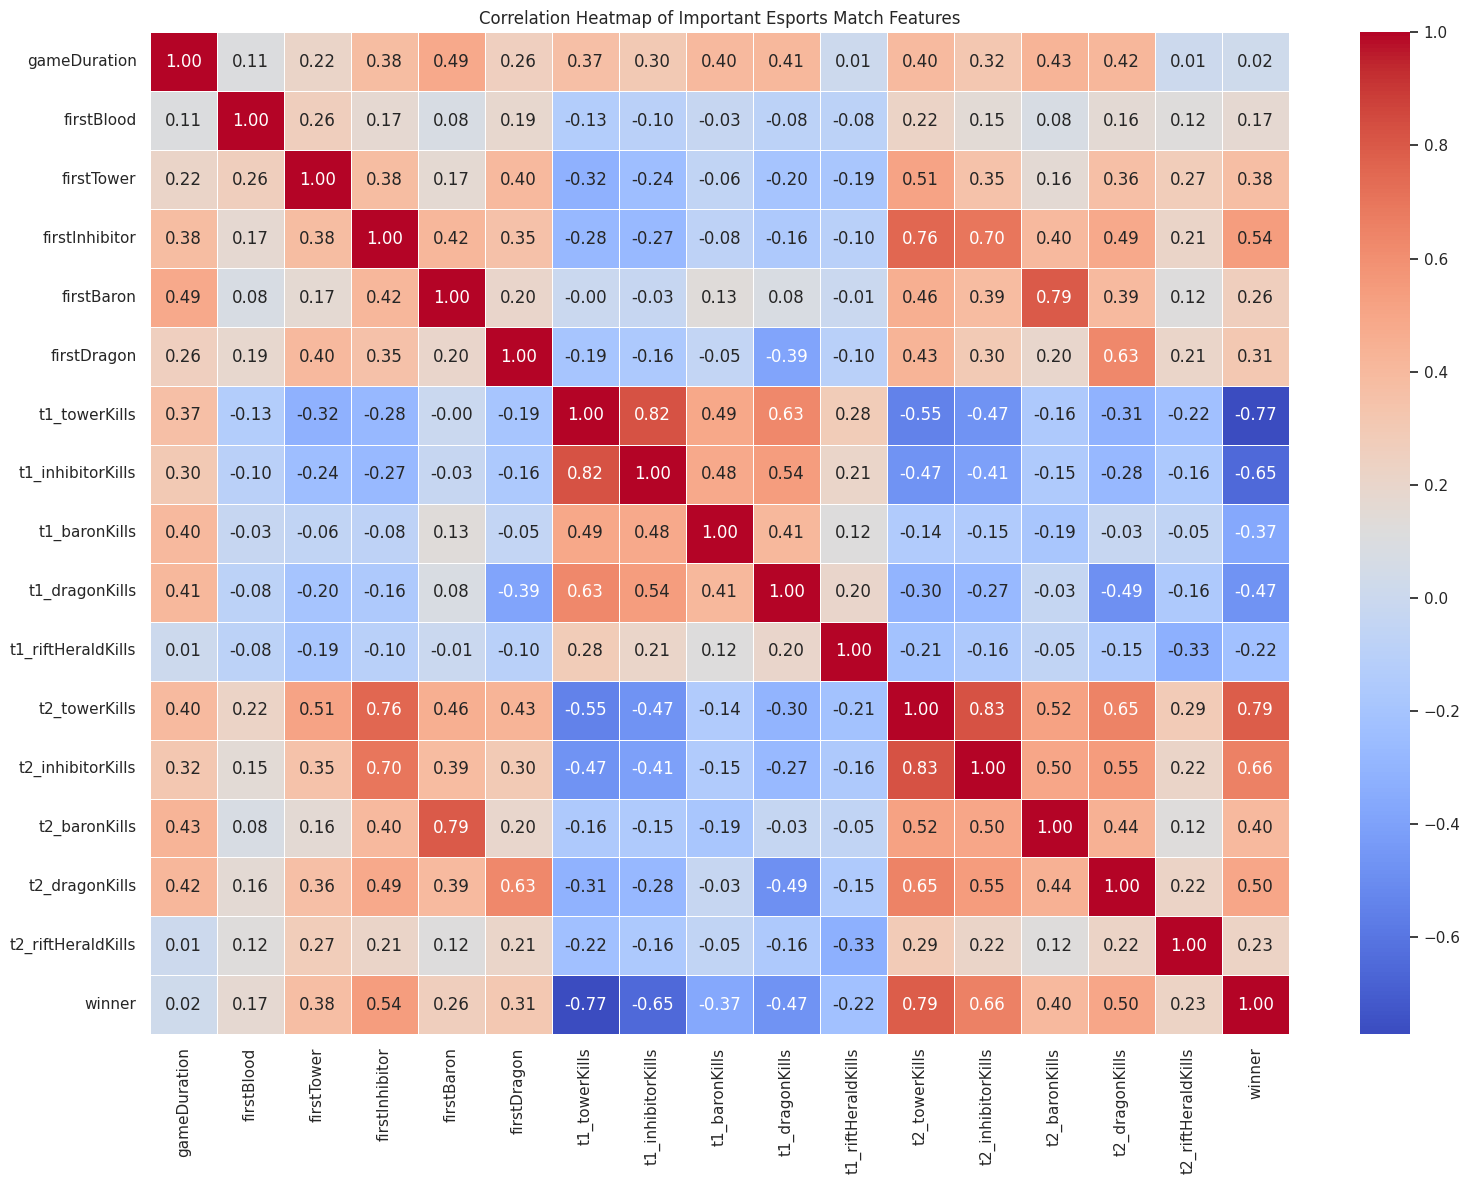

In [23]:
# Correlation heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, square=False)
plt.title("Correlation Heatmap of Important Esports Match Features")
plt.tight_layout()
plt.show()

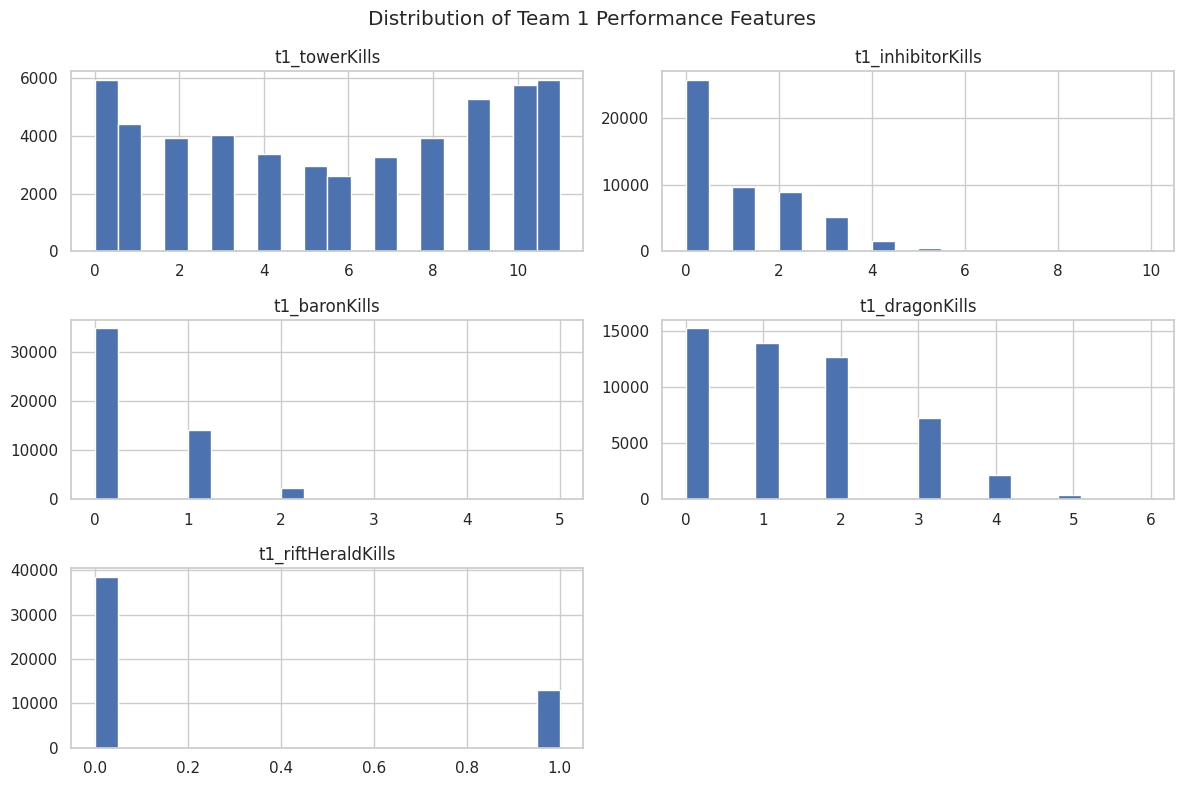

In [24]:
# Team 1 performance distributions
team1_features = [
    't1_towerKills',
    't1_inhibitorKills',
    't1_baronKills',
    't1_dragonKills',
    't1_riftHeraldKills'
]

team1_features = [c for c in team1_features if c in df.columns]

if team1_features:
    df[team1_features].hist(figsize=(12, 8), bins=20)
    plt.suptitle("Distribution of Team 1 Performance Features")
    plt.tight_layout()
    plt.show()

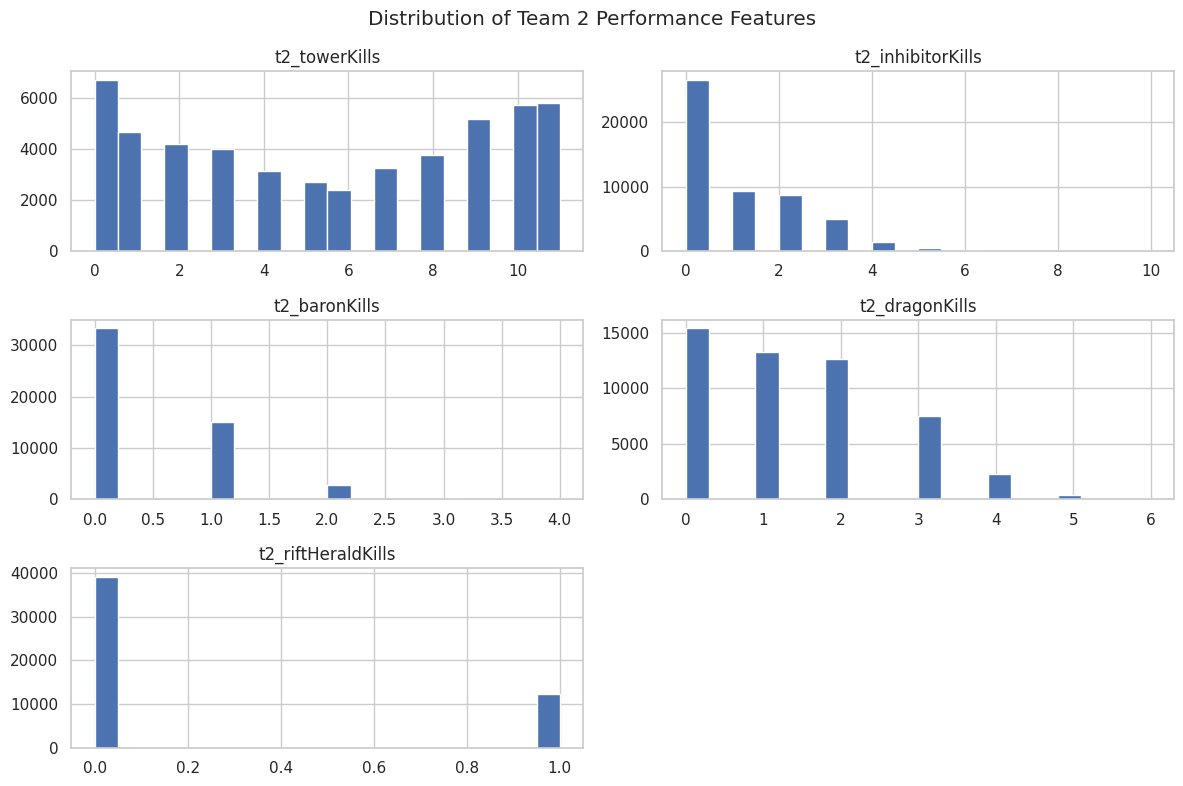

In [25]:
# Team 2 performance distributions
team2_features = [
    't2_towerKills',
    't2_inhibitorKills',
    't2_baronKills',
    't2_dragonKills',
    't2_riftHeraldKills'
]

team2_features = [c for c in team2_features if c in df.columns]

if team2_features:
    df[team2_features].hist(figsize=(12, 8), bins=20)
    plt.suptitle("Distribution of Team 2 Performance Features")
    plt.tight_layout()
    plt.show()

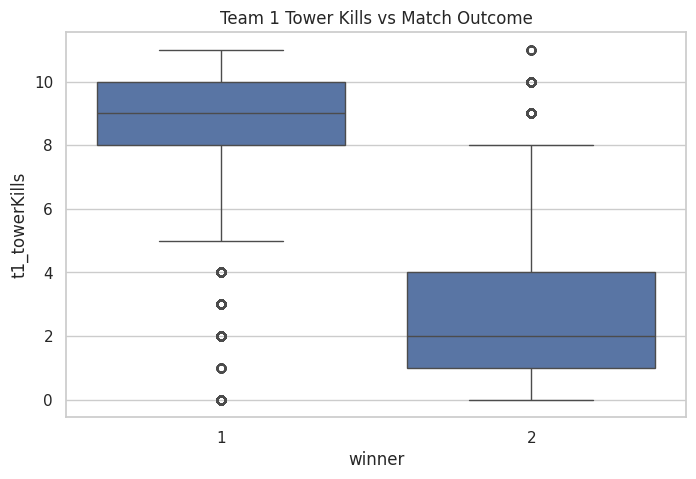

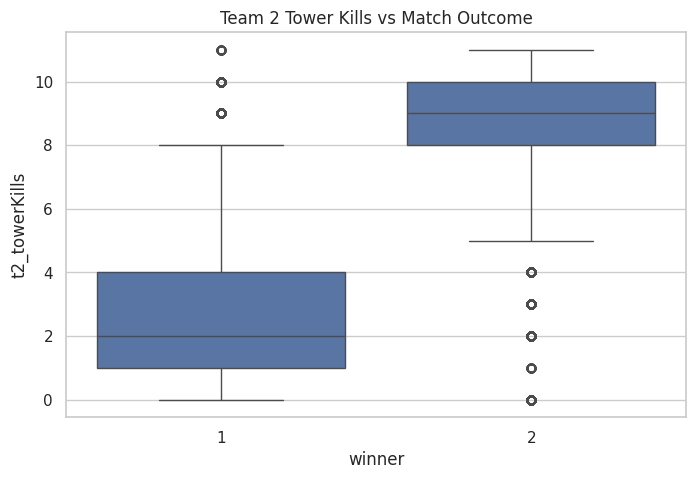

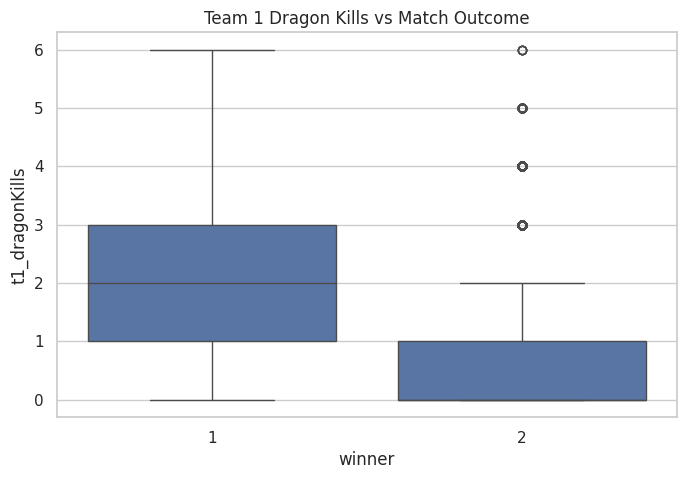

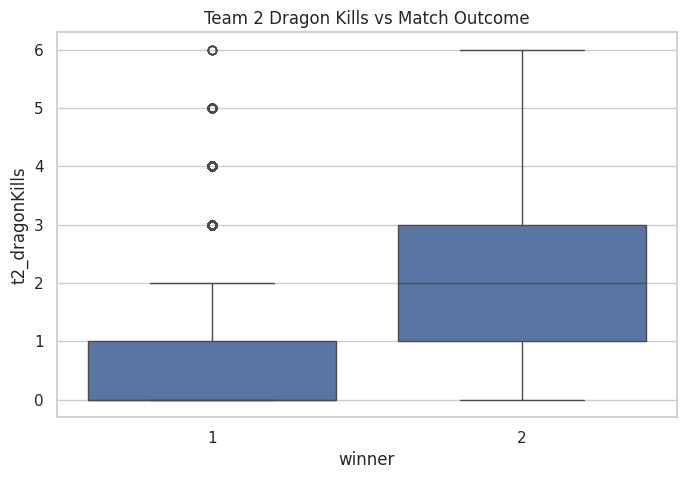

In [26]:
# Compare tower kills with match outcome
for column, title in [
    ('t1_towerKills', 'Team 1 Tower Kills vs Match Outcome'),
    ('t2_towerKills', 'Team 2 Tower Kills vs Match Outcome'),
    ('t1_dragonKills', 'Team 1 Dragon Kills vs Match Outcome'),
    ('t2_dragonKills', 'Team 2 Dragon Kills vs Match Outcome')
]:
    if column in df.columns:
        plt.figure(figsize=(8, 5))
        sns.boxplot(data=df, x='winner', y=column)
        plt.title(title)
        plt.show()

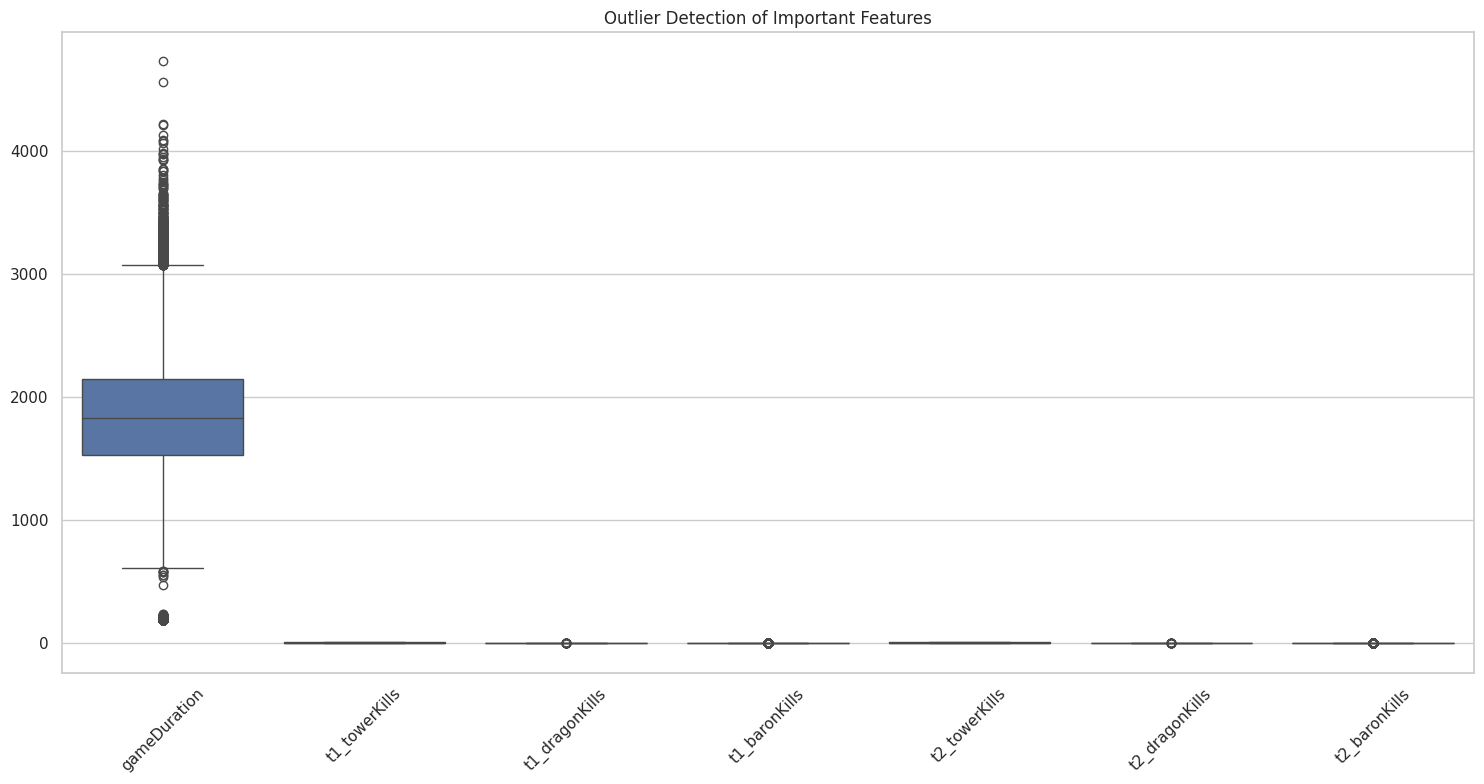

In [27]:
# Outlier detection
features = [
    'gameDuration',
    't1_towerKills', 't1_dragonKills', 't1_baronKills',
    't2_towerKills', 't2_dragonKills', 't2_baronKills'
]

features = [c for c in features if c in df.columns]

if features:
    plt.figure(figsize=(15, 8))
    sns.boxplot(data=df[features])
    plt.xticks(rotation=45)
    plt.title("Outlier Detection of Important Features")
    plt.tight_layout()
    plt.show()

In [28]:
# Average objective comparison
team1_objectives = [c for c in [
    't1_towerKills', 't1_inhibitorKills', 't1_baronKills',
    't1_dragonKills', 't1_riftHeraldKills'
] if c in df.columns]

team2_objectives = [c for c in [
    't2_towerKills', 't2_inhibitorKills', 't2_baronKills',
    't2_dragonKills', 't2_riftHeraldKills'
] if c in df.columns]

print("Team 1 Average Objectives:")
print(df[team1_objectives].mean())

print("\nTeam 2 Average Objectives:")
print(df[team2_objectives].mean())

Team 1 Average Objectives:
t1_towerKills         5.699359
t1_inhibitorKills     1.017537
t1_baronKills         0.372286
t1_dragonKills        1.387182
t1_riftHeraldKills    0.251466
dtype: float64

Team 2 Average Objectives:
t2_towerKills         5.549466
t2_inhibitorKills     0.985084
t2_baronKills         0.414547
t2_dragonKills        1.404370
t2_riftHeraldKills    0.240105
dtype: float64


## EDA Summary

- The target variable is `winner`.
- The notebook checks missing values and duplicate records.
- It analyzes match outcome distribution and important objective features.
- Histograms, boxplots and correlation heatmaps are used for visualization.
- The final preprocessing section prepares the target for deep learning.

In [29]:
# Prepare target variable for Deep Learning
# Original values: 1 = Team 1 wins, 2 = Team 2 wins
df_dl = df.copy()

df_dl['winner_binary'] = df_dl['winner'].map({
    1: 0,
    2: 1
})

print(df_dl['winner_binary'].value_counts())
print("\n0 = Team 1 Wins")
print("1 = Team 2 Wins")

winner_binary
0    26077
1    25413
Name: count, dtype: int64

0 = Team 1 Wins
1 = Team 2 Wins


In [30]:
# Save cleaned dataset for future Deep Learning work
df_dl.to_csv('esports_cleaned_for_deep_learning.csv', index=False)

print("File saved successfully: esports_cleaned_for_deep_learning.csv")

# Download from Google Colab
from google.colab import files
files.download('esports_cleaned_for_deep_learning.csv')

File saved successfully: esports_cleaned_for_deep_learning.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>